# Práctica 3: Resolución de un problema usando aprendizaje automático
# Proyecto: Predicción de Emisiones de CO2 en Vehículos

**Autores:** Daniel Martín del Castillo, David Díaz Gregorio PONED EL NOMBRE!!!
 
**Objetivo:** El objetivo de este notebook es desarrollar un modelo de clasificación capaz de predecir las emisiones de CO2 (g/km) de un vehículo basándose en sus características técnicas y su consumo de combustible.

In [3]:
# Importamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv('co2.csv')

# Visualizamos las primeras filas para confirmar que todo está bien
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


# Análisis Exploratorio de Datos (EDA)
En esta sección analizamos la estructura del dataset para identificar posibles valores nulos, tipos de variables y la relación visual entre las características del motor y las emisiones.

**Detección de Duplicados**
Antes de proceder con el modelo, verificamos si existen registros duplicados en el dataset. La presencia de duplicados puede sesgar el entrenamiento y precisión.

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null 

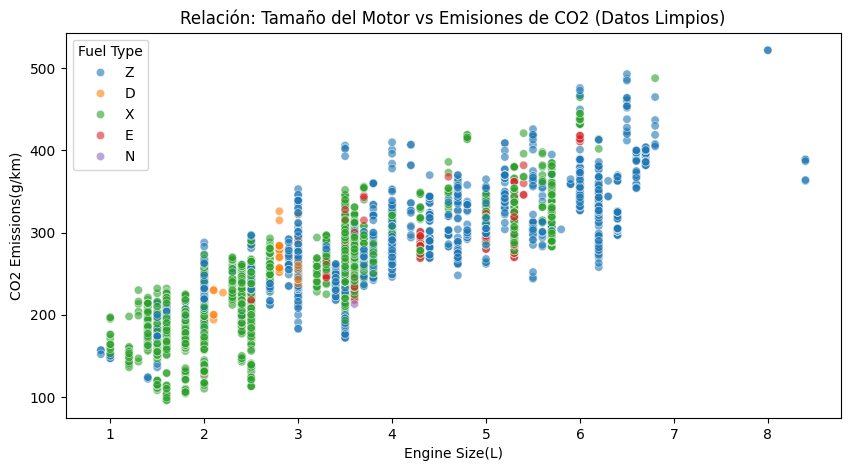

In [4]:
# Información técnica y nulos
print("--- Información del Dataset ---")
df.info()

# Detección y limpieza de duplicados
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas encontradas: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates()
    print("¡Limpieza completada! Filas duplicadas eliminadas.")
    print(f"Tamaño actual del dataset: {df.shape[0]} filas.")

# Gráfico de relación entre el tamaño del motor vs emisiones
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Engine Size(L)', y='CO2 Emissions(g/km)', hue='Fuel Type', alpha=0.6)
plt.title('Relación: Tamaño del Motor vs Emisiones de CO2 (Datos Limpios)')
plt.show()

# Pre-procesamiento y Transformación
En esta fase preparamos los datos siguiendo la estrategia definida en nuestros experimentos previos:
1. **Categorización**: Convertimos las emisiones de CO2 (numéricas) en categorías de impacto ambiental.
2. **Limpieza**: Eliminamos columnas que no aportan valor predictivo o son redundantes.
3. **División**: Separamos los datos en entrenamiento (80%) y test (20%) para evaluar el rendimiento real.

# Limpieza de Datos y Selección de Variables
Tras analizar el dataset original, hemos procedido a eliminar ciertas columnas que podrían perjudicar el rendimiento de nuestros modelos o que resultan redundantes para el objetivo de la predicción:

**Eliminación de la columna Model**: Esta variable contiene el nombre específico de cada modelo de coche. Al haber miles de modelos distintos, incluirla en el modelo obligaría a crear miles de columnas nuevas durante la codificación, lo que haría el entrenamiento excesivamente lento e ineficiente.

**Eliminación de Fuel Consumption Comb (mpg)**: El dataset ya incluye el consumo de combustible en litros por cada 100 km (L/100 km). Mantener ambas columnas es inecesario, ya que ambas representan la misma información en unidades distintas. Hemos optado por mantener la métrica europea (L/100 km) por ser más estándar en nuestro contexto.  

**Eliminación de CO2 Emissions(g/km)**: Al haber transformado el problema en uno de clasificación, eliminamos la variable numérica original para evitar que el modelo tenga acceso directo al valor que queremos predecir en su versión categórica.  

Con esta limpieza, nos aseguramos de que el modelo trabaje únicamente con variables que aportan valor real y facilitan el aprendizaje de patrones generales sobre las marcas y tipos de vehículos.

In [5]:
# Categorizacion del CO2
bins   = [0, 120, 150, 180, 210, 250, 300, float('inf')]
labels = ['<120', '120-150', '150-180', '180-210', '210-250', '250-300', '>300']

df['CO2_categoria'] = pd.cut(df['CO2 Emissions(g/km)'], bins=bins, labels=labels).astype(str)

# Limpieza de columnas
df_modelo = df.drop(columns=['CO2 Emissions(g/km)', 'Model', 'Fuel Consumption Comb (mpg)'])

# Division del dataset
from sklearn.model_selection import train_test_split

X = df_modelo.drop(columns=['CO2_categoria'])
y = df_modelo['CO2_categoria']

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1224)

print(f"Dataset dividido: {x_train.shape[0]} muestras de entreno y {x_test.shape[0]} de test.")
x_train.head()

Dataset dividido: 5025 muestras de entreno y 1257 de test.


,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km)
2343,BMW,SUV - SMALL,2.0,4,AS8,Z,11.7,8.4,10.2
5764,FORD,PICKUP TRUCK - STANDARD,5.0,8,AS10,X,13.9,10.2,12.2
4234,PORSCHE,SUV - SMALL,3.0,6,A7,Z,13.8,10.3,12.3
376,FORD,PICKUP TRUCK - STANDARD,3.7,6,A6,E,18.8,13.7,16.5
1253,BUICK,SUV - STANDARD,3.6,6,A6,X,14.2,9.9,12.3


# Codificación de Variables Categóricas
Para que los algoritmos de aprendizaje automático puedan procesar la información de las variables de texto (como la marca o el tipo de combustible en nuestro caso), utilizamos **OneHotEncoder**. Esta técnica crea columnas binarias para cada categoría, permitiendo que el modelo interprete estas características sin asumir un orden jerárquico.

In [6]:
from sklearn.preprocessing import OneHotEncoder

# Definimos las columnas categoricas a transformar
columnas_cat = ["Make", "Vehicle Class", "Transmission", "Fuel Type"]

# Inicializamos el encoder eliminando la primera columna de cada categoría para evitar redundancia
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Entrenamos el encoder con los datos de entrenamiento
encoder.fit(x_train[columnas_cat])

# Transformamos tanto el conjunto de entrenamiento como el de prueba
train_enc = encoder.transform(x_train[columnas_cat])
test_enc = encoder.transform(x_test[columnas_cat])

# Obtenemos los nombres de las nuevas columnas generadas
cols_nombres = encoder.get_feature_names_out(columnas_cat)

# Creamos los DataFrames finales uniendo las variables numéricas con las nuevas columnas codificadas
x_train_final = x_train.drop(columns=columnas_cat).reset_index(drop=True).join(pd.DataFrame(train_enc, columns=cols_nombres))
x_test_final = x_test.drop(columns=columnas_cat).reset_index(drop=True).join(pd.DataFrame(test_enc, columns=cols_nombres))

print(f"El dataset ahora tiene {x_train_final.shape[1]} columnas.")
x_train_final.head()

El dataset ahora tiene 91 columnas.


,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Make_ALFA ROMEO,Make_ASTON MARTIN,Make_AUDI,Make_BENTLEY,Make_BMW,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,2.0,4,11.7,8.4,10.2,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,5.0,8,13.9,10.2,12.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3.0,6,13.8,10.3,12.3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3.7,6,18.8,13.7,16.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,3.6,6,14.2,9.9,12.3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Experimentación y Comparativa de Modelos
En esta fase procedemos a la experimentación con diferentes tecnologías de aprendizaje automático. El objetivo es evaluar qué algoritmo se adapta mejor a la naturaleza de nuestro dataset de emisiones de CO2 una vez categorizado. 
Para garantizar una comparativa correcta, seguiremos los siguientes pasos:

**-Selección de Tecnologías**: Hemos seleccionado los siguientes 4 algoritmos:
    **Decision Tree (Árbol de Decisión)**: Un modelo basado en reglas lógicas que destaca por su interpretabilidad.  
    **Random Forest**: Un modelo de "ensamble" que combina múltiples árboles para mejorar la precisión y reducir el sobreajuste.  
    **K-Nearest Neighbors (KNN)**: Un algoritmo basado en la "cercanía" o similitud geométrica entre los datos.  
    **Regresión Logística**: Un modelo lineal clásico utilizado como base de referencia para problemas de clasificación multiclase.  
    
**-Métrica de Evaluación**: Utilizaremos el Accuracy (Precisión) como medida principal para cuantificar qué porcentaje de vehículos son clasificados correctamente en su rango de emisiones correspondiente.  

**-Validación**: Todos los modelos se entrenarán con el 80% de los datos y se evaluarán con el 20% restante, que el modelo nunca ha visto, asegurando que los resultados sean representativos de su desempeño real.  

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Definimos los modelos con la configuración que mejor resultados dio al equipo
modelos = {
    "Decision Tree": DecisionTreeClassifier(max_depth=15, random_state=1224),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=1224),
    "KNN": KNeighborsClassifier(n_neighbors=10),
    "Regresión Logística": LogisticRegression(max_iter=1000)
}

resultados = {}

print("--- Iniciando entrenamiento de los modelos ---")

for nombre, modelo in modelos.items():
    # El modelo estudia los datos de entrenamiento (91 columnas)
    modelo.fit(x_train_final, y_train)
    
    # El modelo intenta adivinar las categorías del conjunto de test
    y_pred = modelo.predict(x_test_final)
    
    # Comparamos sus aciertos con la realidad
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc
    print(f"{nombre}: Accuracy = {acc:.4f}")

# Generamos el Ranking final
ranking = sorted(resultados.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*30)
print("RANKING FINAL DE TECNOLOGÍAS")
print("="*30)
for i, (nombre, acc) in enumerate(ranking, 1):
    print(f"{i}. {nombre:<20} | Precisión: {acc:.4f}")

--- Iniciando entrenamiento de los modelos ---
Decision Tree: Accuracy = 0.9586
Random Forest: Accuracy = 0.9578
KNN: Accuracy = 0.9029
Regresión Logística: Accuracy = 0.8974

RANKING FINAL DE TECNOLOGÍAS
1. Decision Tree        | Precisión: 0.9586
2. Random Forest        | Precisión: 0.9578
3. KNN                  | Precisión: 0.9029
4. Regresión Logística  | Precisión: 0.8974


/home/nitram/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Análisis Técnico 
Durante la fase de experimentación, el modelo de Regresión Logística mostró un aviso de tipo **ConvergenceWarning** tras alcanzar el límite de 1000 iteraciones. Esto nos informa de:  
    **-No Linealidad del Problema**: La Regresión Logística intenta encontrar una separación lineal entre las categorías de CO2. El hecho de que el algoritmo no encuentre la solución óptima nos hace ver que la relación entre las especificaciones técnicas del vehículo y sus emisiones es compleja y no lineal.  
    **-Superioridad de los Árboles**: Esto explica por qué el Decision Tree y el Random Forest han obtenido resultados significativamente superiores (aprox. 96% frente al 89%). Los árboles de decisión no intentan trazar una línea, sino que realizan divisiones del espacio de datos, lo que les permite capturar mejor esas relaciones.  
    **-Elección**: Este resultado nos sirve para descartar los modelos lineales para este dataset específico.  La experimentación con múltiples tecnologías nos ha permitido identificar que los modelos basados en árboles son los más adecuados para la naturaleza de los datos de emisiones vehiculares.  

# Interpretación del Modelo
Vamos a analizar qué características técnicas influyen más en la clasificación del nivel de emisiones. Esto nos permite validar si el aprendizaje del algoritmo es coherente con la realidad mecánica de los vehículos.

/tmp/ipykernel_8827/1809959366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


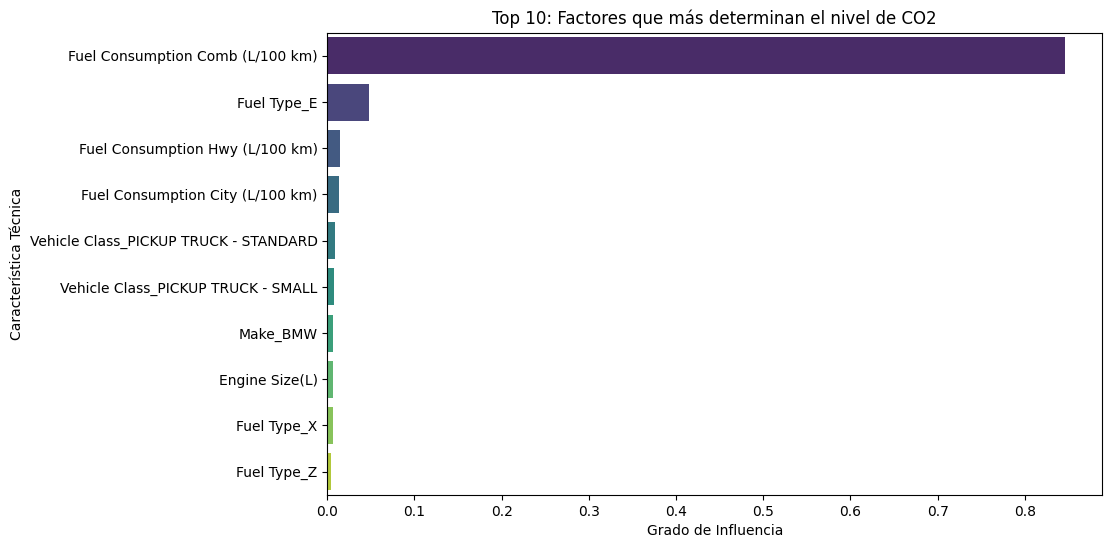

In [8]:
# Extraemos la importancia de las variables
importancias = modelos["Decision Tree"].feature_importances_
nombres_columnas = x_train_final.columns

# Creamos un DataFrame para visualizar las 10 variables más influyentes
df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# Lo mostramos graficamente
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Top 10: Factores que más determinan el nivel de CO2')
plt.xlabel('Grado de Influencia')
plt.ylabel('Característica Técnica')
plt.show()

# Matriz de Confusión
La Matriz de Confusión es una herramienta de validación esencial en problemas de clasificación. Nos permite visualizar el desempeño del algoritmo comparando las etiquetas reales del conjunto de prueba frente a las predicciones realizadas por el modelo. 

En esta matriz:
*   La diagonal principal muestra los aciertos.
*   Los elementos fuera de la diagonal indican en qué categorías específicas el modelo está teniendo dificultades y qué rangos de emisiones tiende a confundir.

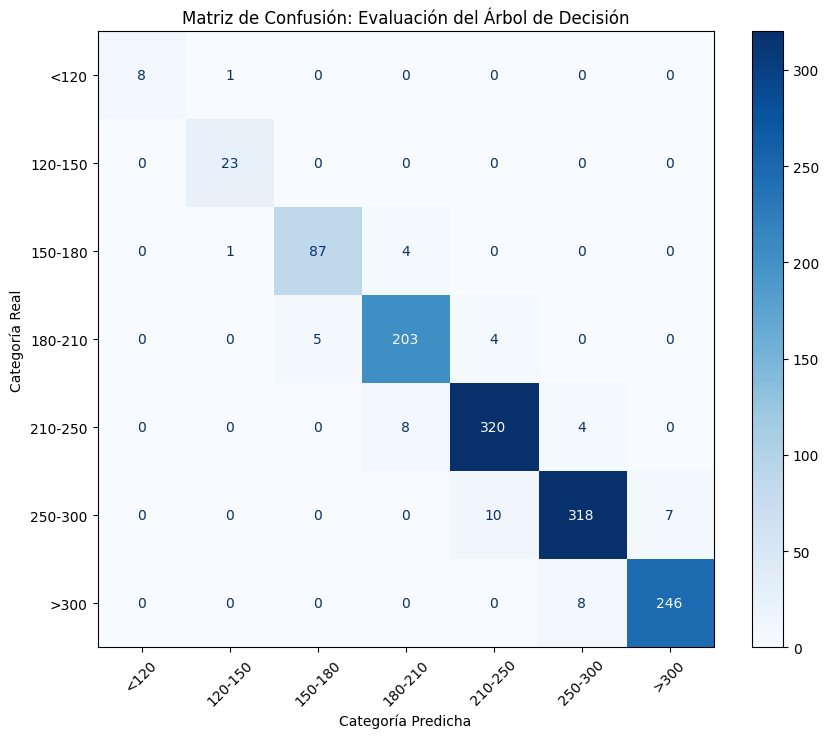

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generamos las predicciones con el modelo ganador (Decision Tree)
y_pred_final = modelos["Decision Tree"].predict(x_test_final)

# Calculamos la matriz de confusion usando las etiquetas definidas previamente
cm = confusion_matrix(y_test, y_pred_final, labels=labels)

# Configuramos la visualizacion grafica
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Dibujamos la matriz con un mapa de colores azul para facilitar la lectura
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

plt.title('Matriz de Confusión: Evaluación del Árbol de Decisión')
plt.xlabel('Categoría Predicha')
plt.ylabel('Categoría Real')
plt.show()

# Análisis de la Matriz de Confusión
El gráfico permite validar visualmente la alta precisión (95.86%) obtenida por el algoritmo, destacando los siguientes puntos:  
    **Predominancia de la Diagonal Principal**: La concentración de valores (tonos azules más oscuros) en la diagonal que cruza el gráfico de arriba a izquierda a abajo a derecha confirma que el modelo clasifica correctamente la inmensa mayoría de los vehículos en todas las categorías de CO2.  
    **Precisión en los Extremos**: El modelo es especialmente robusto al identificar vehículos de muy bajas emisiones (<120) y vehículos de alta contaminación (>300), lo cual es perfecto para aplicaciones de etiquetado ambiental.  
    **Naturaleza de los Errores**: Se observa que los escasos fallos de clasificación ocurren casi solo entre categorías adyacentes. Por ejemplo, algunos vehículos de la clase 180-210 son clasificados como 150-180 o 210-250. Esto ocurre ya que que en los límites de los rangos el modelo pueda oscilar entre categorías vecinas.
    **Ausencia de Errores Críticos**: No se aprecian casos donde el modelo clasifique un vehículo poco contaminante en una categoría de alta contaminación o viceversa, lo que garantiza la fiabilidad. 

**Conclusión final**: La matriz de confusión ratifica que el Árbol de Decisión es una tecnología óptima para este problema, ofreciendo un equilibrio excelente entre acierto general y coherencia en las predicciones.  

# Prueba del Modelo: Predicción de un nuevo vehículo
Una vez validada la precisión de nuestro modelo mediante el conjunto de pruebas y la matriz de confusión, procedemos a realizar una prueba de predicción individual. El objetivo es demostrar la utilidad práctica del algoritmo para clasificar vehículos que no se encuentran en el dataset original. Para ello, haremos lo siguiente:
    **Definición de datos**: Introducimos las características técnicas de un vehículo nuevo (cilindrada, número de cilindros, tipo de combustible y consumos estimados).  **Transformación de datos**: Para que la IA pueda interpretar la información, pasamos los datos de texto por el mismo procesador de Codificación One-Hot que utilizamos durante el entrenamiento. Esto garantiza que el formato sea el correcto. 
    **Ejecución de la Predicción**: Utilizamos el modelo Árbol de Decisión para que analice los datos y asigne automáticamente una de las categorías de emisiones de CO2 definidas.  
    
Esta funcionalidad es la que permitiría automatizar el etiquetado ambiental de nuevos modelos de coches antes de que salgan al mercado.

In [10]:
# Simulamos los datos de un vehículo nuevo (aqui se podrian introducir otros valores para testear)
coche_test = pd.DataFrame([{
    'Make': 'TOYOTA',
    'Vehicle Class': 'COMPACT',
    'Engine Size(L)': 1.8,
    'Cylinders': 4,
    'Transmission': 'AV',
    'Fuel Type': 'X',
    'Fuel Consumption City (L/100 km)': 4.5,
    'Fuel Consumption Hwy (L/100 km)': 4.8,
    'Fuel Consumption Comb (L/100 km)': 4.7
}])

# Pasamos el nuevo coche por el mismo proceso de transformacion de los datos
v_enc = encoder.transform(coche_test[["Make", "Vehicle Class", "Transmission", "Fuel Type"]])
v_cols = encoder.get_feature_names_out(["Make", "Vehicle Class", "Transmission", "Fuel Type"])

# Creamos el DataFrame que la IA entiende 
v_final = coche_test.drop(columns=["Make", "Vehicle Class", "Transmission", "Fuel Type"]).reset_index(drop=True).join(pd.DataFrame(v_enc, columns=v_cols))

# Vemos la prediccion
resultado = modelos["Decision Tree"].predict(v_final)

print(f"Vehículo: Toyota 1.8L (Consumo bajo)")
print(f"La IA clasifica este vehículo en la categoría de emisiones: {resultado[0]}")

Vehículo: Toyota 1.8L (Consumo bajo)
La IA clasifica este vehículo en la categoría de emisiones: <120
